# Recs 001: Game profile — per-review table

## Key Goal

Build a clean per-review game-profile table so each game is represented by consistent review text/features before embedding.

## Decision It Supports

Whether the review-table artifact quality is sufficient to proceed to embedding/indexing.

## Primary Metrics

Row counts/coverage diagnostics (reviews kept, games covered, per-game caps, text completeness).


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(f"Could not find repo root (no pyproject.toml). cwd={here}")


REPO_ROOT = _repo_root()
PROCESSED = REPO_ROOT / "data" / "processed"
TRAIN_PARQUET = PROCESSED / "steam_reviews_cleaned_english_train_norm.parquet"
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "recs"
OUTPUT_REVIEWS_LONG = ARTIFACT_DIR / "game_profile_reviews.parquet"

_src = REPO_ROOT / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import pandas as pd

MAX_REVIEWS_PER_GAME = 200
MIN_REVIEW_CHARS = 30

print("REPO_ROOT:", REPO_ROOT)
print("Train:", TRAIN_PARQUET)
print("Out:", OUTPUT_REVIEWS_LONG)

REPO_ROOT: /home/ryanr/workspace/steam_recommendations
Train: /home/ryanr/workspace/steam_recommendations/data/processed/steam_reviews_cleaned_english_train_norm.parquet
Out: /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_reviews.parquet


## 1) Load train split

In [2]:
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(
        f"Missing {TRAIN_PARQUET}. Run the pipeline in docs/usage_pipeline.md first."
    )

df_train = pd.read_parquet(TRAIN_PARQUET)
print(df_train.shape)
print(df_train[["app_id", "app_name", "recommended", "review"]].dtypes)

(5574220, 27)
app_id         int64
app_name         str
recommended    int64
review           str
dtype: object


## 2) Keep **recommended == 1** only

Processed Parquet stores `recommended` as **`int64`** (`0` / `1`).

**Why thumbs-up only?** Profile signal for “similar games” — see earlier discussion in git history / product notes; ablate with mixed reviews if you want later.

In [3]:
# Drop review_id 212 because it's not in english.
df_train = df_train[~((df_train["review_id"] == 212))]

In [4]:
# int64 0/1 in current processed Parquet; bool also supported if schema changes
rec = df_train["recommended"]
pos_mask = rec if rec.dtype == bool else rec.astype(int).eq(1)

pos = df_train.loc[pos_mask, ["app_id", "app_name", "review_id", "review"]].copy()
pos["review"] = pos["review"].fillna("").astype(str)
pos = pos[pos["review"].str.len() >= MIN_REVIEW_CHARS]
print("positive rows:", len(pos), "games:", pos["app_id"].nunique())

positive rows: 3335364 games: 315


## 3) Per-review rows (cap per game)

Deterministic: sort by `review_id`, take the first **`MAX_REVIEWS_PER_GAME`** reviews per game. Each row is one review — **equal weight** when `recs_002` averages embeddings.

In [5]:
long_rows: list[dict] = []
for app_id, g in pos.groupby("app_id", sort=True):
    g_sorted = g.sort_values("review_id")
    n_avail = len(g_sorted)
    g_sub = g_sorted.head(MAX_REVIEWS_PER_GAME)
    for _, r in g_sub.iterrows():
        long_rows.append(
            {
                "app_id": app_id,
                "app_name": r["app_name"],
                "review_id": int(r["review_id"]),
                "review": r["review"],
                "review_len": len(r["review"]),
            }
        )

reviews_long = pd.DataFrame(long_rows)
print(reviews_long.shape)
reviews_long.head(3)

(62147, 5)


,app_id,app_name,review_id,review,review_len
0,70,Half-Life,71,My favorite LAN-party and killing-time Interne...,217
1,70,Half-Life,451,The game that started it all!\n\nBefore HL2 wa...,461
2,70,Half-Life,1816,"15 yrs after it's release, I finally beat this...",468


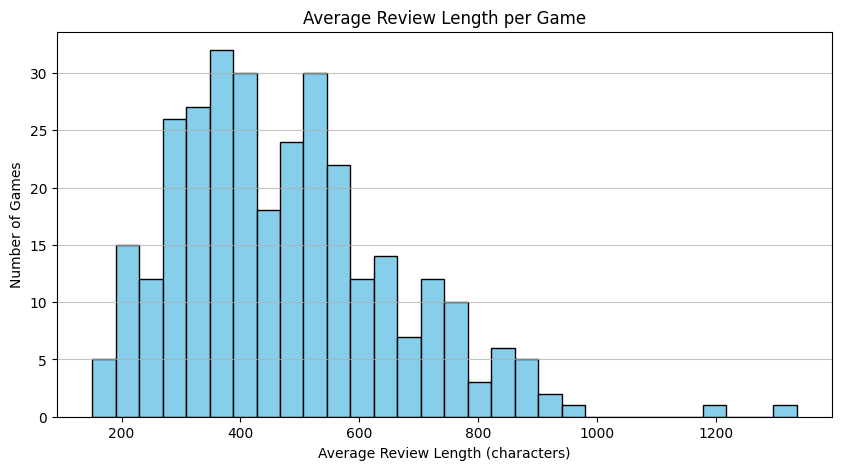

In [12]:
import matplotlib.pyplot as plt

# Calculate average review length per game
avg_review_len_per_game = reviews_long.groupby("app_name")["review_len"].mean()

plt.figure(figsize=(10, 5))
plt.hist(avg_review_len_per_game, bins=30, color="skyblue", edgecolor="black")
plt.title("Average Review Length per Game")
plt.xlabel("Average Review Length (characters)")
plt.ylabel("Number of Games")
plt.grid(axis='y', alpha=0.75)
plt.show()

## 4) Optional: review text lengths

Per-review length still matters for **truncation** in `recs_002` (`MAX_CHARS_PER_REVIEW`), not for a single concat blob.

In [6]:
rc = reviews_long["review"].str.len()
print("chars per review: min", rc.min(), "median", rc.median(), "max", rc.max())

chars per review: min 30 median 211.0 max 8000


In [7]:
reviews_long['app_name'].value_counts()

app_name
Half-Life                                200
Counter-Strike: Source                   200
Half-Life 2: Episode Two                 200
Portal 2                                 200
X Rebirth                                200
                                        ... 
Identity                                 107
Battle Royale Trainer                     94
Senren＊Banka                              81
三国群英传8 Heroes of the Three Kingdoms 8     14
Neon Hardcorps                             7
Name: count, Length: 315, dtype: int64

# Reviewing game count

##  Validate existing artifact

Validate `artifacts/recs/game_profile_reviews.parquet` produced by the pipeline job before using it in **`recs_002`**.

In [8]:
# QA-only: validate existing artifact generated by pipeline job.
if not OUTPUT_REVIEWS_LONG.is_file():
    raise FileNotFoundError(
        f"Missing {OUTPUT_REVIEWS_LONG}. Run scripts/recs_job_game_profiles.py first."
    )

artifact_df = pd.read_parquet(OUTPUT_REVIEWS_LONG)
print("Validated existing artifact:", OUTPUT_REVIEWS_LONG)
print("artifact rows:", len(artifact_df), "computed rows:", len(reviews_long))
print("artifact games:", artifact_df["app_id"].nunique(), "computed games:", reviews_long["app_id"].nunique())

Validated existing artifact: /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_reviews.parquet
artifact rows: 62147 computed rows: 62147
artifact games: 315 computed games: 315
